# Análisis de Dependencias - SBOM Analyzer

Consolidación y análisis cuantitativo de SBOMs generados con Syft para 16 repositorios activos de PrefectHQ.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print("✓ Librerías cargadas correctamente")

✓ Librerías cargadas correctamente


In [2]:
# Configurar ruta a los resultados
results_path = Path("../results")

# Listar todos los archivos SBOM (los que terminan en _sbom.json y no están vacíos)
sbom_files = sorted([f for f in results_path.glob("*_sbom.json") if f.stat().st_size > 0])

print(f"✓ Se encontraron {len(sbom_files)} archivos SBOM válidos")
print("\nPrimeros 5 archivos:")
for f in sbom_files[:5]:
    print(f"  - {f.name} ({f.stat().st_size / 1024:.1f} KB)")

✓ Se encontraron 16 archivos SBOM válidos

Primeros 5 archivos:
  - actions-updatecli-apply_sbom.json (14.5 KB)
  - colin_sbom.json (527.3 KB)
  - dev-log_sbom.json (11.7 KB)
  - fastmcp_sbom.json (773.9 KB)
  - marvin_sbom.json (1102.4 KB)


In [3]:
# Cargar el primer SBOM para ver su estructura
ejemplo = sbom_files[0]
print(f"Analizando: {ejemplo.name}\n")

with open(ejemplo, 'r') as f:
    data = json.load(f)

# Ver las claves principales del JSON
print("Claves principales del JSON:")
for key in data.keys():
    print(f"  - {key}")

# Ver el formato del SBOM
if 'bomFormat' in data:
    print(f"\nFormato: {data['bomFormat']}")
    print(f"Versión: {data.get('specVersion', 'N/A')}")

Analizando: actions-updatecli-apply_sbom.json

Claves principales del JSON:
  - artifacts
  - artifactRelationships
  - files
  - source
  - distro
  - descriptor
  - schema


In [4]:
# Explorar la estructura de los artifacts (componentes)
artifacts = data.get('artifacts', [])

print(f"Total de componentes en {ejemplo.name}: {len(artifacts)}")

# Ver la estructura del primer componente
if artifacts:
    print("\nEstructura del primer componente:")
    primer_comp = artifacts[0]
    for key, value in primer_comp.items():
        if isinstance(value, (str, int, float, bool)) or value is None:
            print(f"  - {key}: {value}")
        elif isinstance(value, list):
            print(f"  - {key}: [lista con {len(value)} elementos]")
        elif isinstance(value, dict):
            print(f"  - {key}: {{diccionario}}")
    
    print("\nPrimer componente completo:")
    print(json.dumps(primer_comp, indent=2)[:1000] + "...")

Total de componentes en actions-updatecli-apply_sbom.json: 6

Estructura del primer componente:
  - id: 89fc164eb66dd39a
  - name: 8398a7/action-slack
  - version: v3
  - type: github-action
  - foundBy: github-actions-usage-cataloger
  - locations: [lista con 1 elementos]
  - licenses: [lista con 0 elementos]
  - language: 
  - cpes: [lista con 6 elementos]
  - purl: pkg:github/8398a7/action-slack@v3
  - metadataType: github-actions-use-statement
  - metadata: {diccionario}

Primer componente completo:
{
  "id": "89fc164eb66dd39a",
  "name": "8398a7/action-slack",
  "version": "v3",
  "type": "github-action",
  "foundBy": "github-actions-usage-cataloger",
  "locations": [
    {
      "path": "/.github/workflows/notify-on-failure.yaml",
      "accessPath": "/.github/workflows/notify-on-failure.yaml",
      "annotations": {
        "evidence": "primary"
      }
    }
  ],
  "licenses": [],
  "language": "",
  "cpes": [
    {
      "cpe": "cpe:2.3:a:8398a7\\/action-slack:8398a7\\/action-

In [5]:
def parse_sbom(file_path, repo_name):
    """Extrae los componentes de un SBOM y los devuelve como lista de diccionarios"""
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    artifacts = data.get('artifacts', [])
    components = []
    
    for artifact in artifacts:
        # Extraer licencias (puede ser lista vacía o lista de objetos con 'name')
        license_names = []
        for lic in artifact.get('licenses', []):
            if isinstance(lic, dict) and 'name' in lic:
                license_names.append(lic['name'])
            elif isinstance(lic, str):
                license_names.append(lic)
        
        component = {
            'repo': repo_name,
            'name': artifact.get('name', ''),
            'version': artifact.get('version', ''),
            'type': artifact.get('type', ''),
            'purl': artifact.get('purl', ''),
            'language': artifact.get('language', ''),
            'licenses': ', '.join(license_names) if license_names else None,
            'cpe_count': len(artifact.get('cpes', []))
        }
        components.append(component)
    
    return components

# Procesar todos los SBOMs
all_components = []

for sbom_file in sbom_files:
    repo_name = sbom_file.stem.replace('_sbom', '')
    print(f"Procesando {repo_name}...")
    
    components = parse_sbom(sbom_file, repo_name)
    all_components.extend(components)
    print(f"  → {len(components)} componentes")

# Crear DataFrame
df_components = pd.DataFrame(all_components)

print(f"\n✓ DataFrame creado con {len(df_components)} componentes")
print(f"  Columnas: {list(df_components.columns)}")

Procesando actions-updatecli-apply...
  → 6 componentes
Procesando colin...
  → 190 componentes
Procesando dev-log...
  → 6 componentes
Procesando fastmcp...
  → 303 componentes
Procesando marvin...
  → 414 componentes
Procesando prefab...
  → 518 componentes
Procesando prefect-cloud...
  → 69 componentes
Procesando prefect-design...
  → 253 componentes
Procesando prefect-fastmcp-demos...
  → 93 componentes
Procesando prefect-helm...
  → 26 componentes
Procesando prefect-mcp-server...
  → 256 componentes
Procesando prefect-operator...
  → 99 componentes
Procesando prefect...
  → 1181 componentes
Procesando prometheus-prefect-exporter...
  → 12 componentes
Procesando terraform-prefect-bucket-sensor...
  → 7 componentes
Procesando terraform-provider-prefect...
  → 107 componentes

✓ DataFrame creado con 3540 componentes
  Columnas: ['repo', 'name', 'version', 'type', 'purl', 'language', 'licenses', 'cpe_count']


In [6]:
# Primeras filas del DataFrame
print("Primeras 10 filas del DataFrame:")
df_components.head(10)


Primeras 10 filas del DataFrame:


,repo,name,version,type,purl,language,licenses,cpe_count
0,actions-updatecli-apply,8398a7/action-slack,v3,github-action,pkg:github/8398a7/action-slack@v3,,None,6
1,actions-updatecli-apply,actions/checkout,v6,github-action,pkg:github/actions/checkout@v6,,None,1
2,actions-updatecli-apply,actions/checkout,v6,github-action,pkg:github/actions/checkout@v6,,None,1
3,actions-updatecli-apply,jdx/mise-action,v4,github-action,pkg:github/jdx/mise-action@v4,,None,6
4,actions-updatecli-apply,prefecthq/actions-mise-upgrade,main,github-action,pkg:github/prefecthq/actions-mise-upgrade@main,,None,10
5,actions-updatecli-apply,prefecthq/actions-updatecli-apply,${{ github.head_ref }},github-action,pkg:github/prefecthq/actions-updatecli-apply@%...,,None,10
6,colin,actions/checkout,v4,github-action,pkg:github/actions/checkout@v4,,None,1
7,colin,actions/checkout,v4,github-action,pkg:github/actions/checkout@v4,,None,1
8,colin,actions/checkout,v4,github-action,pkg:github/actions/checkout@v4,,None,1
9,colin,actions/checkout,v4,github-action,pkg:github/actions/checkout@v4,,None,1


In [7]:
# Estadísticas básicas
print("=== ESTADÍSTICAS BÁSICAS ===\n")
print(f"Total de componentes: {len(df_components)}")
print(f"Repositorios analizados: {df_components['repo'].nunique()}")
print(f"Tipos de componentes únicos: {df_components['type'].nunique()}")
print(f"Componentes con licencia: {df_components['licenses'].notna().sum()}")
print(f"Componentes sin licencia: {df_components['licenses'].isna().sum()}")

=== ESTADÍSTICAS BÁSICAS ===

Total de componentes: 3540
Repositorios analizados: 16
Tipos de componentes únicos: 5
Componentes con licencia: 0
Componentes sin licencia: 3540


=== DISTRIBUCIÓN POR TIPO DE COMPONENTE ===

type
python                    1670
npm                       1329
github-action              379
go-module                  149
github-action-workflow      13
Name: count, dtype: int64


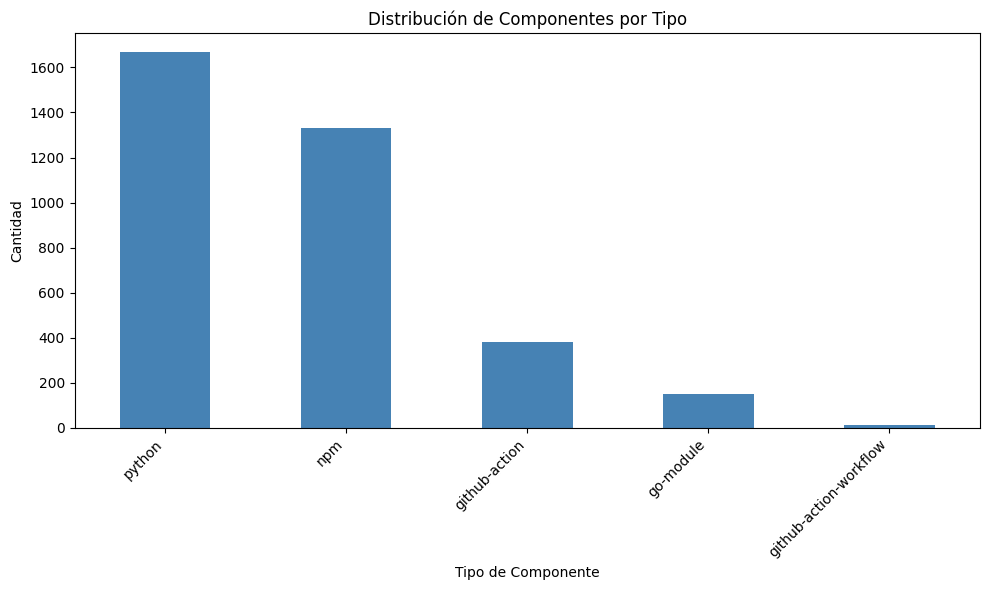

In [8]:
# Distribución por tipo de componente
print("=== DISTRIBUCIÓN POR TIPO DE COMPONENTE ===\n")
type_counts = df_components['type'].value_counts()
print(type_counts)

# Visualización
plt.figure(figsize=(10, 6))
type_counts.plot(kind='bar', color='steelblue')
plt.title('Distribución de Componentes por Tipo')
plt.xlabel('Tipo de Componente')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


=== COMPONENTES POR REPOSITORIO ===

repo
prefect                            1181
prefab                              518
marvin                              414
fastmcp                             303
prefect-mcp-server                  256
prefect-design                      253
colin                               190
terraform-provider-prefect          107
prefect-operator                     99
prefect-fastmcp-demos                93
prefect-cloud                        69
prefect-helm                         26
prometheus-prefect-exporter          12
terraform-prefect-bucket-sensor       7
actions-updatecli-apply               6
dev-log                               6
Name: count, dtype: int64


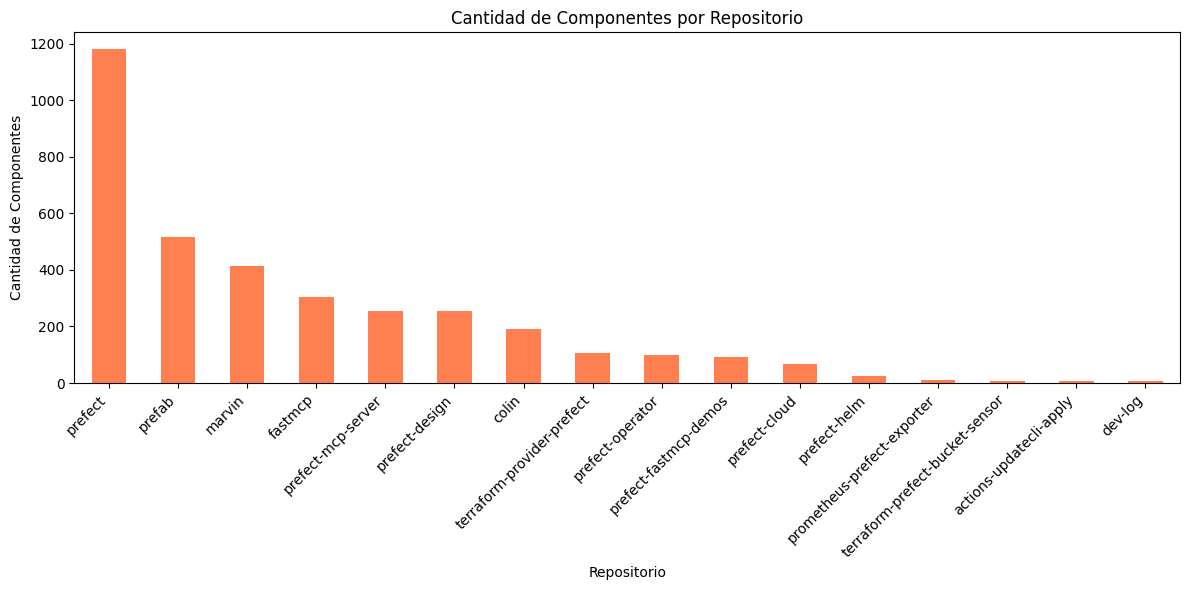

In [9]:
# Componentes por repositorio
print("\n=== COMPONENTES POR REPOSITORIO ===\n")
repo_counts = df_components['repo'].value_counts()
print(repo_counts)

plt.figure(figsize=(12, 6))
repo_counts.plot(kind='bar', color='coral')
plt.title('Cantidad de Componentes por Repositorio')
plt.xlabel('Repositorio')
plt.ylabel('Cantidad de Componentes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
# Métricas cuantitativas para el informe
print("=== MÉTRICAS CUANTITATIVAS DE DEPENDENCIAS ===\n")

# Totales
total_componentes = len(df_components)
total_repos = df_components['repo'].nunique()

print(f"📦 TOTALES:")
print(f"  • Repositorios analizados: {total_repos}")
print(f"  • Componentes totales: {total_componentes}")
print(f"  • Promedio de componentes por repo: {total_componentes/total_repos:.1f}")

# Por ecosistema
print(f"\n🌐 DISTRIBUCIÓN POR ECOSISTEMA:")
ecosystem_counts = df_components['type'].value_counts()
for eco, count in ecosystem_counts.items():
    pct = (count / total_componentes) * 100
    print(f"  • {eco}: {count} ({pct:.1f}%)")

# Top 10 componentes más usados
print(f"\n🔝 TOP 10 COMPONENTES MÁS FRECUENTES:")
top_components = df_components['name'].value_counts().head(10)
for name, count in top_components.items():
    print(f"  • {name}: {count} repositorios")

# Componentes únicos vs duplicados
componentes_unicos = df_components['name'].nunique()
print(f"\n🔄 DEDUPLICACIÓN:")
print(f"  • Componentes únicos: {componentes_unicos}")
print(f"  • Componentes totales: {total_componentes}")
print(f"  • Tasa de reutilización: {total_componentes/componentes_unicos:.2f}x")

=== MÉTRICAS CUANTITATIVAS DE DEPENDENCIAS ===

📦 TOTALES:
  • Repositorios analizados: 16
  • Componentes totales: 3540
  • Promedio de componentes por repo: 221.2

🌐 DISTRIBUCIÓN POR ECOSISTEMA:
  • python: 1670 (47.2%)
  • npm: 1329 (37.5%)
  • github-action: 379 (10.7%)
  • go-module: 149 (4.2%)
  • github-action-workflow: 13 (0.4%)

🔝 TOP 10 COMPONENTES MÁS FRECUENTES:
  • actions/checkout: 116 repositorios
  • astral-sh/setup-uv: 43 repositorios
  • actions/setup-node: 14 repositorios
  • actions/create-github-app-token: 13 repositorios
  • docker/setup-buildx-action: 13 repositorios
  • ipython: 12 repositorios
  • jdx/mise-action: 11 repositorios
  • docker/build-push-action: 11 repositorios
  • annotated-types: 10 repositorios
  • anyio: 10 repositorios

🔄 DEDUPLICACIÓN:
  • Componentes únicos: 1516
  • Componentes totales: 3540
  • Tasa de reutilización: 2.34x


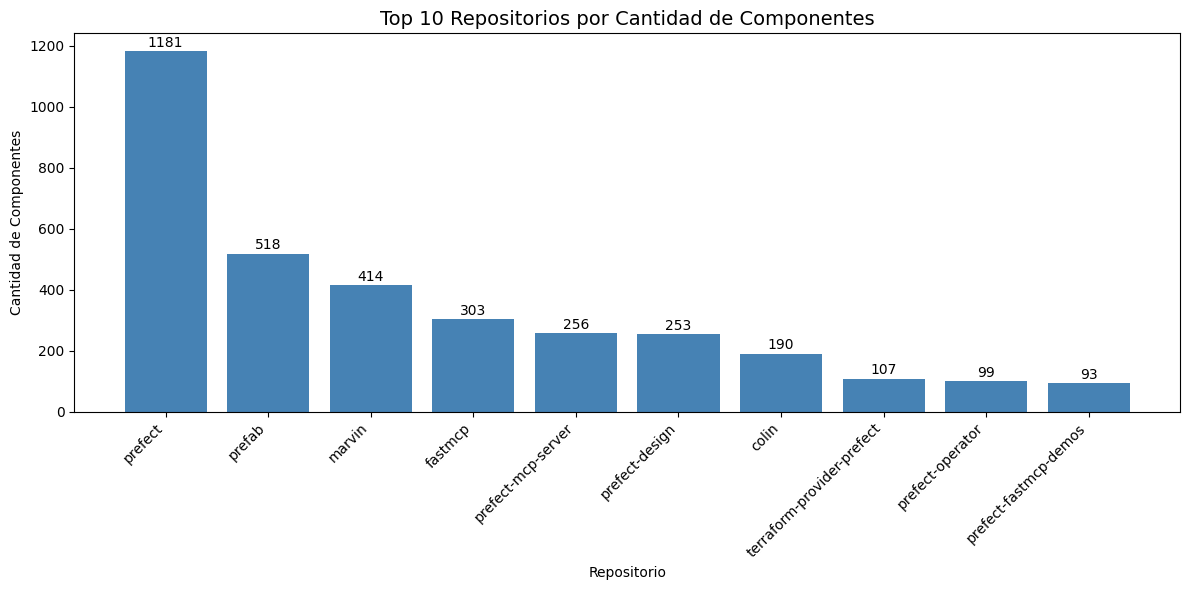

In [11]:
# Top 10 repositorios con más componentes
top_repos = df_components['repo'].value_counts().head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(top_repos.index, top_repos.values, color='steelblue')
plt.title('Top 10 Repositorios por Cantidad de Componentes', fontsize=14)
plt.xlabel('Repositorio')
plt.ylabel('Cantidad de Componentes')
plt.xticks(rotation=45, ha='right')

# Agregar valores en las barras
for bar, value in zip(bars, top_repos.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()

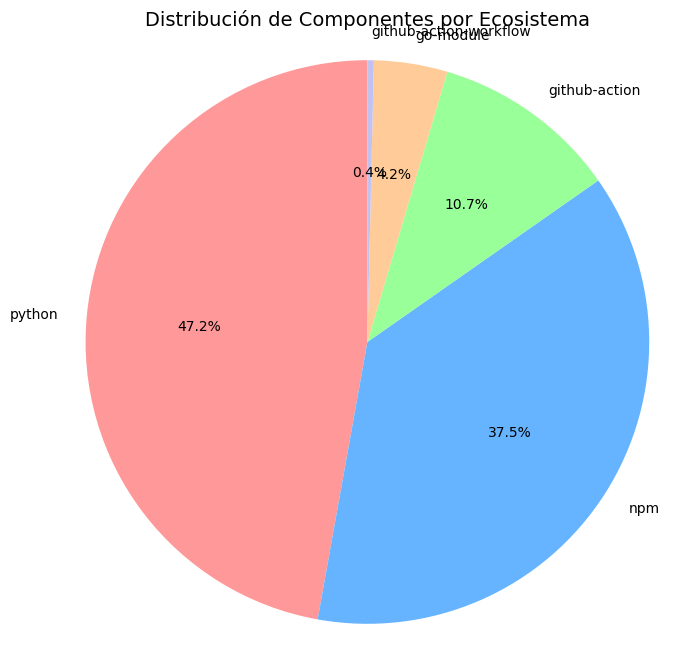

In [12]:
# Gráfico de torta para ecosistemas
plt.figure(figsize=(8, 8))
ecosystem_counts = df_components['type'].value_counts()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']
plt.pie(ecosystem_counts.values, labels=ecosystem_counts.index, 
        autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Distribución de Componentes por Ecosistema', fontsize=14)
plt.axis('equal')
plt.show()

In [13]:
# Componentes que tienen CPE (identificadores de vulnerabilidad)
con_cpe = df_components[df_components['cpe_count'] > 0]
sin_cpe = df_components[df_components['cpe_count'] == 0]

print(f"Componentes CON CPE: {len(con_cpe)} ({len(con_cpe)/len(df_components)*100:.1f}%)")
print(f"Componentes SIN CPE: {len(sin_cpe)} ({len(sin_cpe)/len(df_components)*100:.1f}%)")

# Por ecosistema
print("\nComponentes con CPE por ecosistema:")
cpe_by_type = con_cpe.groupby('type').size().sort_values(ascending=False)
for eco, count in cpe_by_type.items():
    total_eco = ecosystem_counts[eco]
    pct = (count / total_eco) * 100
    print(f"  • {eco}: {count}/{total_eco} ({pct:.1f}%)")

Componentes CON CPE: 3524 (99.5%)
Componentes SIN CPE: 16 (0.5%)

Componentes con CPE por ecosistema:
  • python: 1670/1670 (100.0%)
  • npm: 1329/1329 (100.0%)
  • github-action: 379/379 (100.0%)
  • go-module: 133/149 (89.3%)
  • github-action-workflow: 13/13 (100.0%)


In [14]:
# Exportar DataFrame para Persona 3
output_path = Path("../results")
output_file = output_path / "componentes_consolidados.csv"
df_components.to_csv(output_file, index=False)

print(f"✓ DataFrame exportado exitosamente")
print(f"  Archivo: {output_file}")
print(f"  Registros: {len(df_components)}")

✓ DataFrame exportado exitosamente
  Archivo: ../results/componentes_consolidados.csv
  Registros: 3540


## Conclusiones

### Hallazgos principales:
- **3,540 componentes** analizados en 16 repositorios
- **Python (47.2%)** y **npm (37.5%)** son los ecosistemas dominantes
- **PrefectHQ/prefect** es el repositorio más complejo con 1,181 componentes
- **99.5% de componentes tienen CPEs** asignados (3,524 de 3,540)

### Archivo generado:
- `results/componentes_consolidados.csv` - Dataset consolidado para análisis de vulnerabilidades